In [1]:
%load_ext autoreload
%autoreload 2

import os, sys 
sys.path.append("../models")
sys.path.append("../models/src_foley")
sys.path.append("../models/src_plotting")
# !pip install qutip
from src_foley.load_all import *
from src_plotting.load_all import *
from qutip import *
import numpy as np
import h5py 
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from tqdm import tqdm

In [8]:
chain_length = 1
params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': None,
    'system_starts': None,
    'photon_starts': [0],
    'photon_freqs': [0.98],
    'photon_max_nums': [50],
    'mus' : [[[[0, 0,  -1.16222121, 0], [0, 0, 0, 0], 
           [-1.16222121, 0, 0, 1.459734 ], [0, 0, 1.459734 , 0]]] * 3] * chain_length,
    'spatial': False,
    'couplings': None,
    'model': 'pzw',
    'positions': [],
    'descr': "",
    'filepath':None,
}

params['system_e_levels'] = np.array([[-1.13727441, -0.5319925 , -0.16945967,  0.48077953]])

mini = 0
maxi = 3.5
step = 0.01
eigenstates=12

systems_4ls_pzw = get_4ls_hamiltonians(params, chain_length, mini , maxi, step)

100%|██████████| 350/350 [00:00<00:00, 2541.53it/s]


In [14]:
chain_length = 1
params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': None,
    'system_starts': None,
    'photon_starts': [0],
    'photon_freqs': [0.98],
    'photon_max_nums': [50],
    'mus' : [[[[0, 0,  -1.16222121, 0], [0, 0, 0, 0], 
           [-1.16222121, 0, 0, 1.459734 ], [0, 0, 1.459734 , 0]]] * 3] * chain_length,
    'spatial': False,
    'couplings': None,
    'model': 'minus',
    'positions': [],
    'descr': "",
    'filepath':None,
}

params['system_e_levels'] = np.array([[-1.13727441, -0.5319925 , -0.16945967,  0.48077953]])

mini = 0
maxi = 3.5
step = 0.01
eigenstates=12

systems_4ls_minus = get_4ls_hamiltonians(params, chain_length, mini , maxi, step)

100%|██████████| 350/350 [00:00<00:00, 2845.74it/s]


In [10]:
# Replicating figure 4 with Foley Equation
chain_length = 1
params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': None,
    'system_starts': None,
    'photon_starts': [0],
    'photon_freqs': [0.98],
    'photon_max_nums': [50],
    'mus' : [[[[0, 0,  -1.16222121, 0], [0, 0, 0, 0], 
           [-1.16222121, 0, 0, 1.459734 ], [0, 0, 1.459734 , 0]]] * 3] * chain_length,
    'spatial': False,
    'couplings': None,
    'model': 'dseH2_pzw',
    'positions': [],
    'descr': "",
    'filepath':None,
}

params['system_e_levels'] = np.array([[-1.13727441, -0.5319925, -0.16945967,  0.48077953]])

mini = 0
maxi = 3.5
step = 0.01
eigenstates=12

systems_4ls_dse = get_4ls_hamiltonians(params, chain_length, mini , maxi, step)

100%|██████████| 350/350 [00:00<00:00, 1867.63it/s]


In [11]:
params = {
    'base_coupling': None,
    'system_e_levels': None,
    'photon_freqs': [0.98],
    'photon_max_nums': [50],
    'spatial': False,
    'lambdas': None,
    'mus': None,
    'model' : "pzw",
    'positions': None,
    'descr': "",
    'filepath': "/scratch/avd383/qed-ci/H2_chain"
}

chain_length = 1
params['system_e_levels'] = np.array(["H2"])

mini = 0
maxi = 3.5
step = 0.01
eigenstates = 12

systems_H2 = get_hamiltonians(params, chain_length, mini , maxi, step)

100%|██████████| 350/350 [00:04<00:00, 81.31it/s]


In [12]:
params = {
    'base_coupling': None,
    'system_e_levels': None,
    'photon_freqs': [0.98],
    'photon_max_nums': [50],
    'spatial': False,
    'lambdas': None,
    'mus': None,
    'model' : "minus",
    'positions': None,
    'descr': "",
    'filepath': "/scratch/avd383/qed-ci/H2_chain"
}

chain_length = 1
params['system_e_levels'] = np.array(["H2"])

mini = 0
maxi = 3.5
step = 0.01
eigenstates = 12

systems_H2_minus = get_hamiltonians(params, chain_length, mini , maxi, step)

100%|██████████| 350/350 [00:03<00:00, 91.26it/s] 


100%|██████████| 350/350 [00:08<00:00, 38.94it/s]


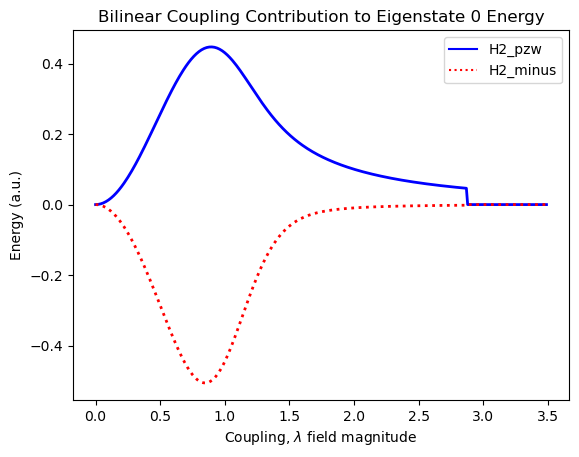

In [28]:
plot_compare([systems_4ls_minus, systems_4ls_pzw], 
             [0], mini, maxi, step, 
             xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="blc", 
             models_s=["H2_pzw", "H2_minus", "4ls_minus", "4ls_minus2", "4ls_dse_pzw"])


100%|██████████| 350/350 [00:13<00:00, 25.50it/s]


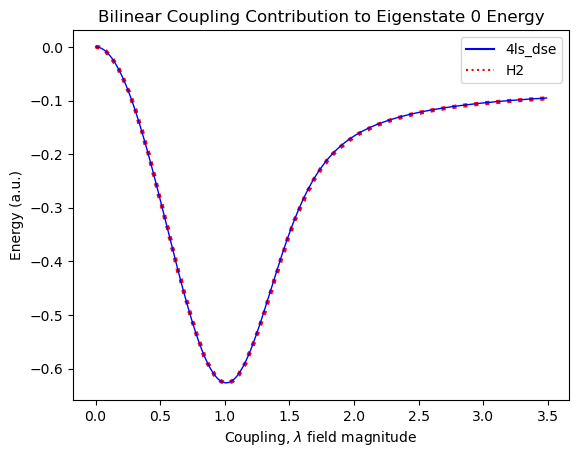

100%|██████████| 350/350 [00:13<00:00, 25.71it/s]


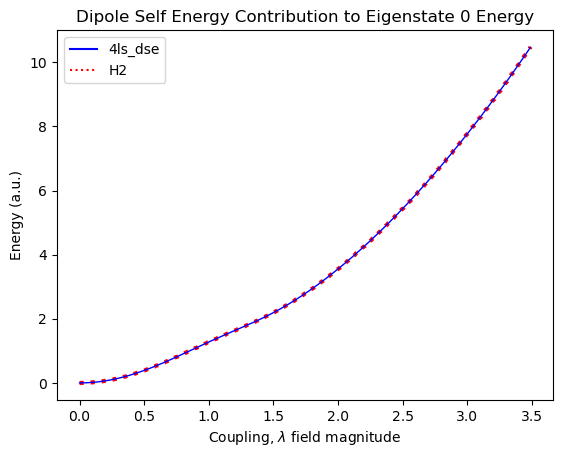

100%|██████████| 350/350 [00:13<00:00, 25.38it/s]


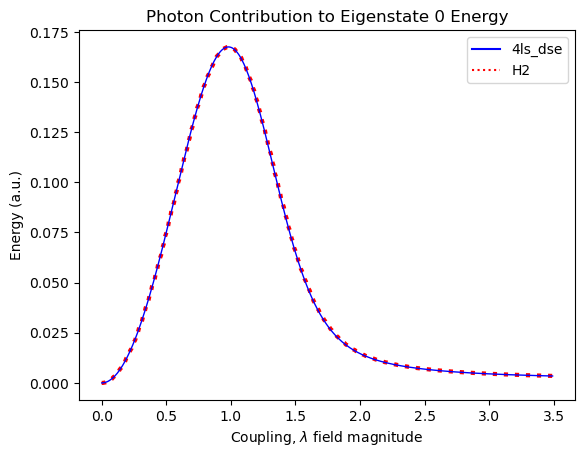

100%|██████████| 350/350 [00:13<00:00, 25.72it/s]


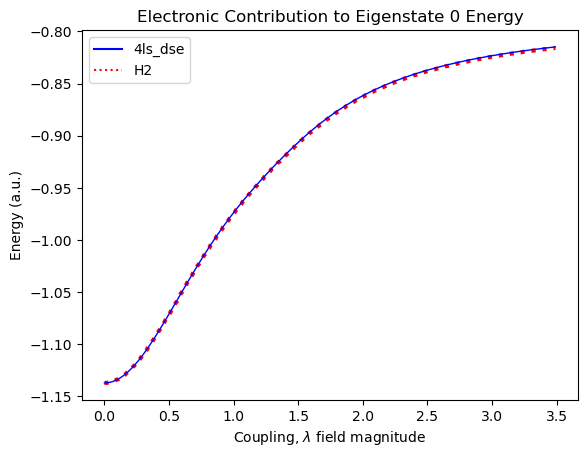

In [20]:
plot_compare(systems_4ls_dse, systems_H2, [0], mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="blc", model1="4ls_dse", model2="H2")
plot_compare(systems_4ls_dse, systems_H2, [0], mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="dse", model1="4ls_dse", model2="H2")
plot_compare(systems_4ls_dse, systems_H2, [0], mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="photon", model1="4ls_dse", model2="H2")
plot_compare(systems_4ls_dse, systems_H2, [0], mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="elec", model1="4ls_dse", model2="H2")

100%|██████████| 350/350 [00:10<00:00, 31.91it/s]


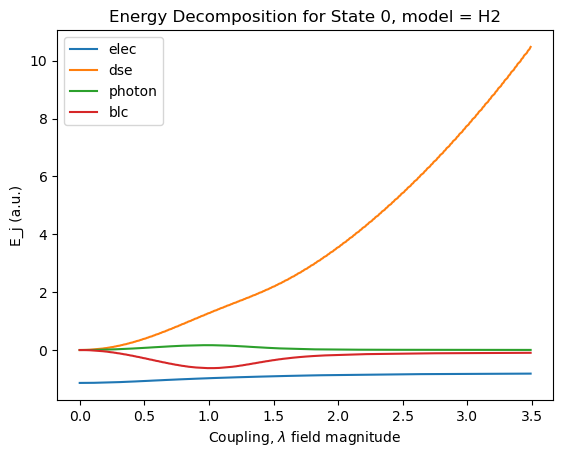

100%|██████████| 350/350 [00:02<00:00, 129.25it/s]


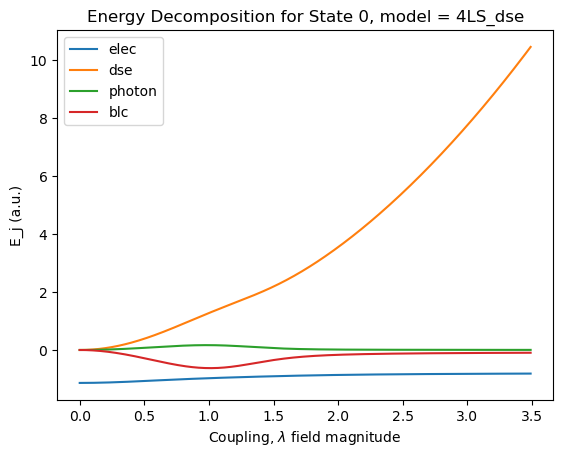

100%|██████████| 350/350 [00:12<00:00, 28.55it/s]


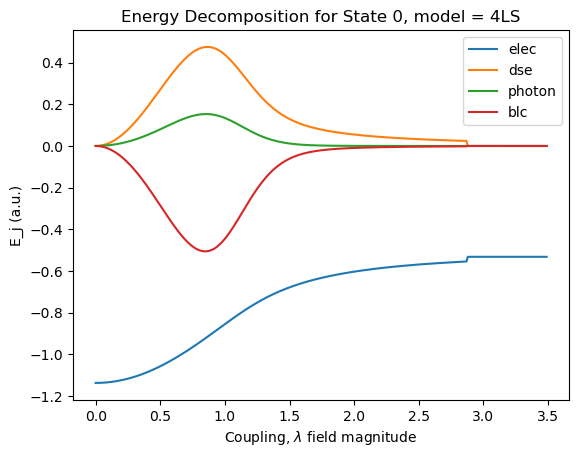

In [21]:
plot_eng_comp(systems_H2, 0, mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", model="H2", lims=[])
plot_eng_comp(systems_4ls_dse, 0, mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", model="4LS_dse", lims=[])
plot_eng_comp(systems_4ls, 0, mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", model="4LS", lims=[])

100%|██████████| 350/350 [00:15<00:00, 22.11it/s]


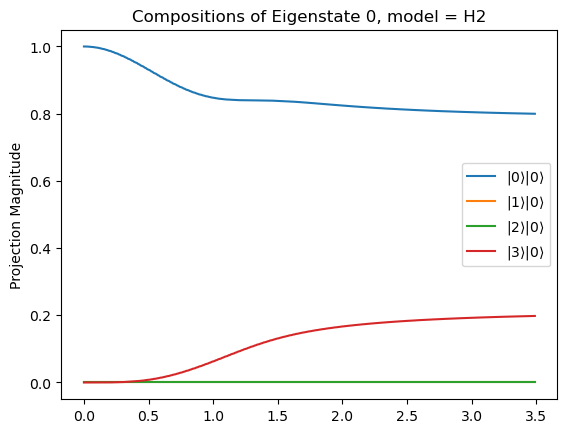

100%|██████████| 350/350 [00:02<00:00, 123.32it/s]


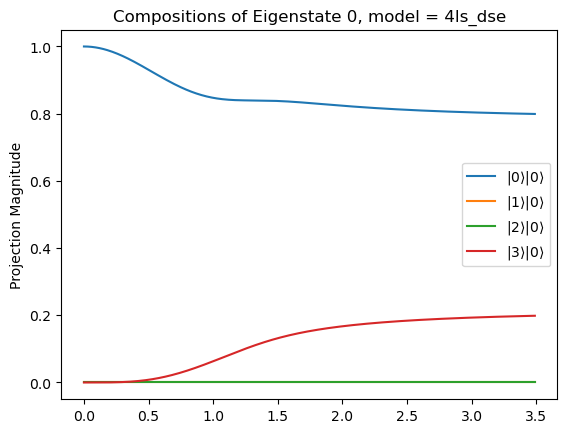

100%|██████████| 350/350 [00:13<00:00, 26.23it/s]


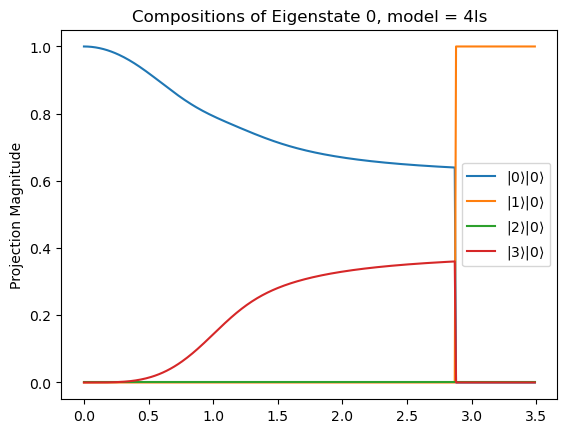

In [22]:
op_list = [[[0], [0]], [[1], [0]], [[2], [0]], [[3], [0]]]
plot_state_comp(systems_H2, 0, op_list, mini, maxi, step, xlabel="", model="H2")
plot_state_comp(systems_4ls_dse, 0, op_list, mini, maxi, step, xlabel="", model="4ls_dse")
plot_state_comp(systems_4ls, 0, op_list, mini, maxi, step, xlabel="", model="4ls")

100%|██████████| 350/350 [00:30<00:00, 11.49it/s]


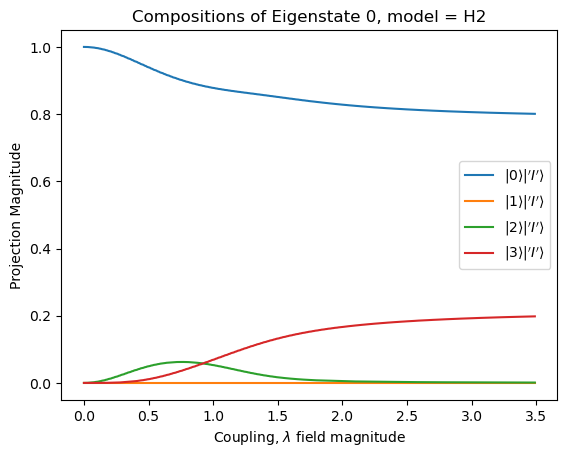

100%|██████████| 350/350 [00:03<00:00, 99.99it/s] 


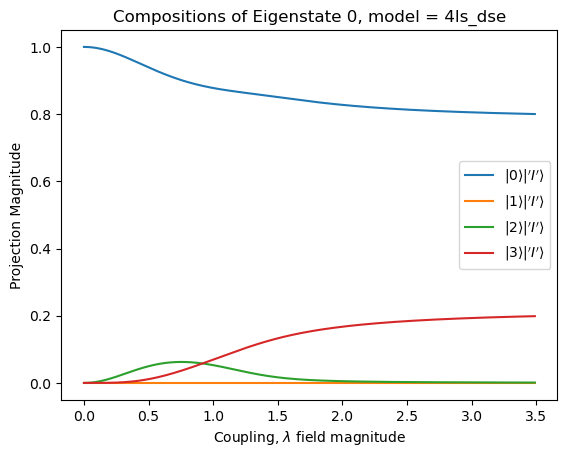

100%|██████████| 350/350 [00:17<00:00, 20.46it/s]


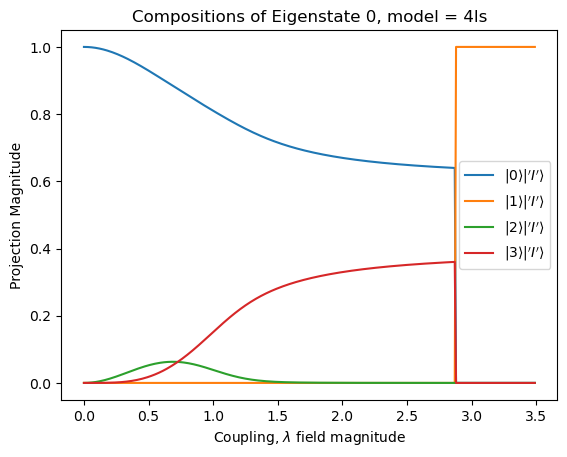

In [23]:
op_list = [[[0], ['I']], [[1], ['I']], [[2], ['I']], [[3], ['I']]]
plot_state_comp(systems_H2, 0, op_list, mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", model="H2")
plot_state_comp(systems_4ls_dse, 0, op_list, mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", model="4ls_dse")
plot_state_comp(systems_4ls, 0, op_list, mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", model="4ls")

100%|██████████| 350/350 [00:04<00:00, 70.61it/s]


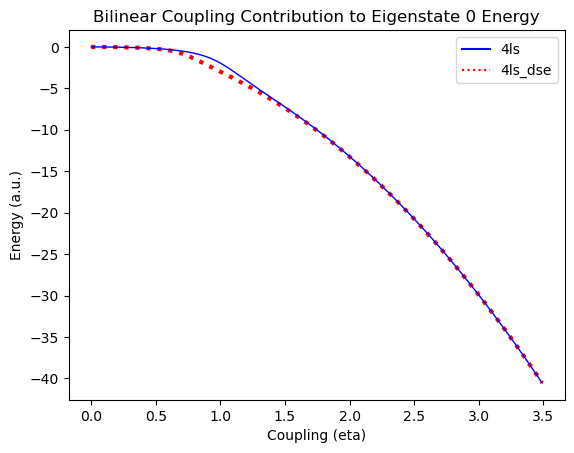

100%|██████████| 350/350 [00:04<00:00, 70.73it/s]


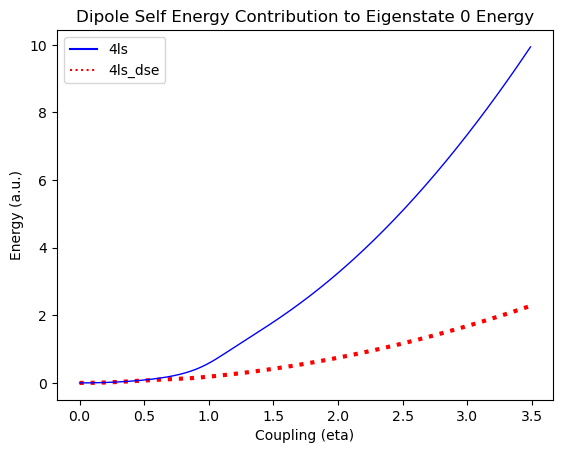

100%|██████████| 350/350 [00:04<00:00, 71.35it/s]


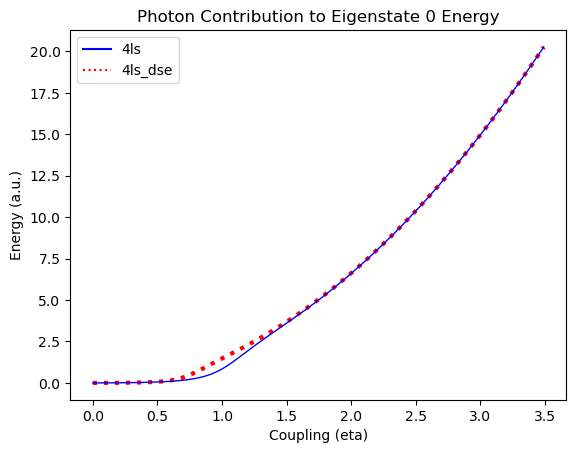

100%|██████████| 350/350 [00:04<00:00, 70.94it/s]


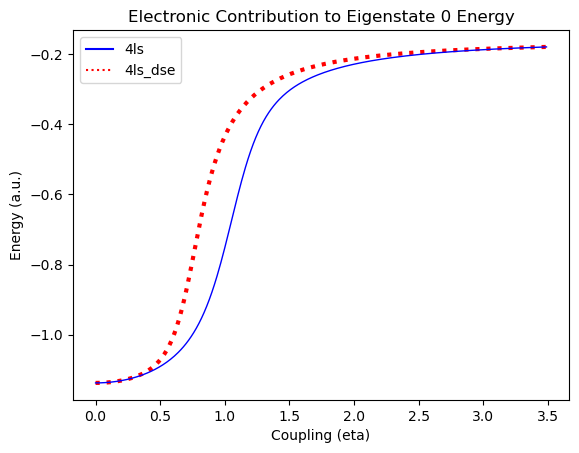

In [51]:
plot_compare(systems_4ls, systems_4ls_dse, [0], mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="blc", model1="4ls", model2="4ls_dse")
plot_compare(systems_4ls, systems_4ls_dse, [0], mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="dse", model1="4ls", model2="4ls_dse")
plot_compare(systems_4ls, systems_4ls_dse, [0], mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="photon", model1="4ls", model2="4ls_dse")
plot_compare(systems_4ls, systems_4ls_dse, [0], mini, maxi, step, xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="elec", model1="4ls", model2="4ls_dse")

100%|██████████| 350/350 [00:14<00:00, 24.65it/s]


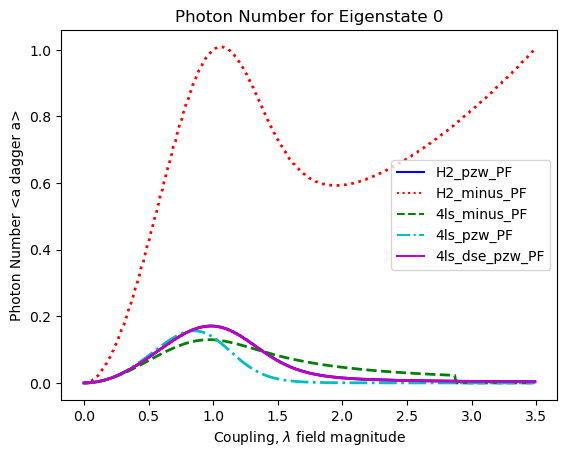

In [12]:
plot_compare([systems_H2, systems_H2_minus, systems_4ls_minus, systems_4ls_pzw, systems_4ls_dse], 
             [0], mini, maxi, step, 
             xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="pn", 
             models_s=["H2_pzw_PF", "H2_minus_PF", "4ls_minus_PF", "4ls_pzw_PF", "4ls_dse_pzw_PF"])

100%|██████████| 350/350 [00:09<00:00, 38.82it/s]


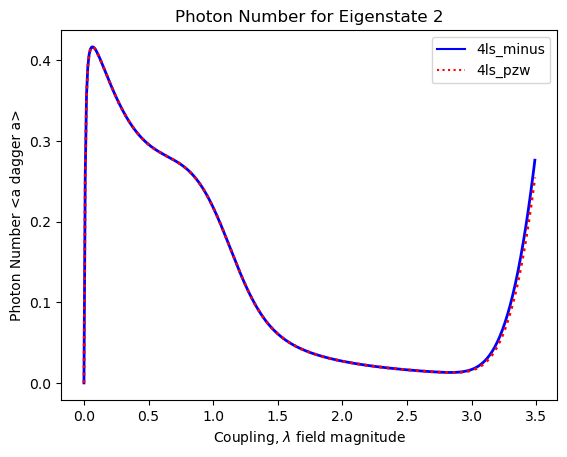

In [21]:
plot_compare([systems_4ls_minus, systems_4ls_pzw], 
             [2], mini, maxi, step, 
             xlabel="Coupling, $\lambda$ field magnitude", lims=[], operator="pn", 
             models_s=["4ls_minus", "4ls_pzw"])